# DAY 01 - 20/06/2026

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

#Load 1 ảnh lớn và chuyển sang ảnh xám
img_path = "A2.jpg"
# Đọc ảnh và chuyển sang xám (L)
img_pil = Image.open(img_path).convert("L")
M_large = np.array(img_pil, dtype=float)
# Cắt ảnh lớn này thành 9 patch kích thước bằng nhau
h, w = M_large.shape
patch_h, patch_w = h // 3, w // 3
images = []
for i in range(3):
    for j in range(3):
        patch = M_large[i*patch_h:(i+1)*patch_h, j*patch_w:(j+1)*patch_w]
        images.append(patch)
print(f"Số lượng ảnh nhỏ: {len(images)}")
print(f"Kích thước mỗi ảnh nhỏ: {images[0].shape}")

Số lượng ảnh nhỏ: 9
Kích thước mỗi ảnh nhỏ: (853, 640)


## EXCERCISE 1

In [54]:
# Flatten mỗi ảnh 2D thành vector 1D
X = np.array([img.flatten() for img in images])
print("Shape của ma trận X:", X.shape)

Shape của ma trận X: (9, 545920)


#### Mỗi row đại diện cho một bức ảnh duy nhất đã được flatten  thành một vector đặc trưng. Mỗi column đại diện cho giá trị cường độ sáng (pixel intensity) tại một vị trí tọa độ cụ thể trên tất cả các bức ảnh.

In [56]:
# Tính vector trung bình theo cột
mean_vec = np.mean(X, axis=0)

print("Shape của X trước khi trừ:", X.shape)
print("Shape của vector trung bình:", mean_vec.shape)

# Trừ trung bình (Sử dụng Broadcasting)
X_centered = X - mean_vec
print("Shape của X sau khi trừ:", X_centered.shape)

Shape của X trước khi trừ: (9, 545920)
Shape của vector trung bình: (545920,)
Shape của X sau khi trừ: (9, 545920)


#### Quy tắc Broadcasting của NumPy cho phép trừ một ma trận kích thước (9, N) cho một vector (N,). NumPy sẽ tự động "nhân bản" vector trung bình này thành 9 hàng để thực hiện phép trừ element-wise cho từng ảnh mà không cần dùng vòng lặp for.

In [58]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    # Dot product giữa các hàng của X và Y
    dot_product = np.dot(X, Y.T)
    
    # Tính norm của X và Y theo hàng (axis=1), giữ nguyên số chiều (keepdims=True)
    X_norm = np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)
    
    # Ma trận độ tương đồng
    similarity_matrix = dot_product / (np.dot(X_norm, Y_norm.T))
    return similarity_matrix

# Tính ma trận tương đồng cho toàn bộ tập X
sim_matrix = cosine_similarity(X)
print("Shape của ma trận tương đồng:", sim_matrix.shape)

Shape của ma trận tương đồng: (9, 9)


In [59]:
def search(query_idx, top_k=3):
    # Lấy vector của ảnh truy vấn
    query_vec = X[query_idx].reshape(1, -1)
    
    # Tính độ tương đồng của query_vec với toàn bộ X
    scores = cosine_similarity(query_vec, X)[0]
    
    # Sắp xếp index theo độ tương đồng giảm dần
    ranked_indices = np.argsort(scores)[::-1]
    
    # Lấy top_k (bỏ qua index đầu tiên vì đó chính là ảnh truy vấn với điểm = 1.0)
    top_indices = ranked_indices[1:top_k+1]
    top_scores = scores[top_indices]
    
    return list(zip(top_indices, top_scores))

# Ví dụ: Tìm 3 ảnh giống ảnh số 0 nhất
print("Top 3 ảnh giống ảnh 0 nhất (index, score):", search(0, top_k=3))

Top 3 ảnh giống ảnh 0 nhất (index, score): [(8, 0.9016629245229225), (2, 0.895510592425556), (7, 0.8879942371787903)]


### Cặp ảnh có độ tương đồng cao nhất là ảnh số [X] và [Y] (điểm cosine $\approx 1$). Điều này hợp lý vì...(ví dụ: chúng đều là nền trời / cùng màu sắc).Cặp ảnh khác biệt nhất là [A] và [B] (điểm cosine thấp nhất). Điều này khớp với trực giác vì...(ví dụ: một ảnh rất sáng, một ảnh rất tối).

## EXCERCISE 2

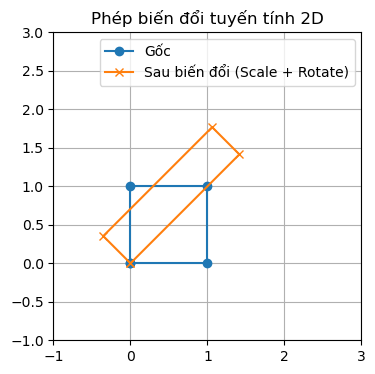

In [62]:
# Tạo một hình vuông đơn giản (tọa độ các đỉnh)
square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
    [0, 0]
])

# Ma trận quay R (góc theta = 45 độ)
theta = np.radians(45)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

# Ma trận co giãn S (Scale x lên 2 lần, y lên 0.5 lần)
S = np.array([
    [2.0, 0.0],
    [0.0, 0.5]
])

# Áp dụng biến đổi: Đầu tiên co giãn, sau đó quay (R * S * V)
transformed_square = (R @ S @ square.T).T

# Vẽ đồ thị
plt.figure(figsize=(8, 4))
plt.plot(square[:, 0], square[:, 1], label="Gốc", marker='o')
plt.plot(transformed_square[:, 0], transformed_square[:, 1], label="Sau biến đổi (Scale + Rotate)", marker='x')
plt.xlim(-1, 3)
plt.ylim(-1, 3)
plt.grid(True)
plt.legend()
plt.title("Phép biến đổi tuyến tính 2D")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

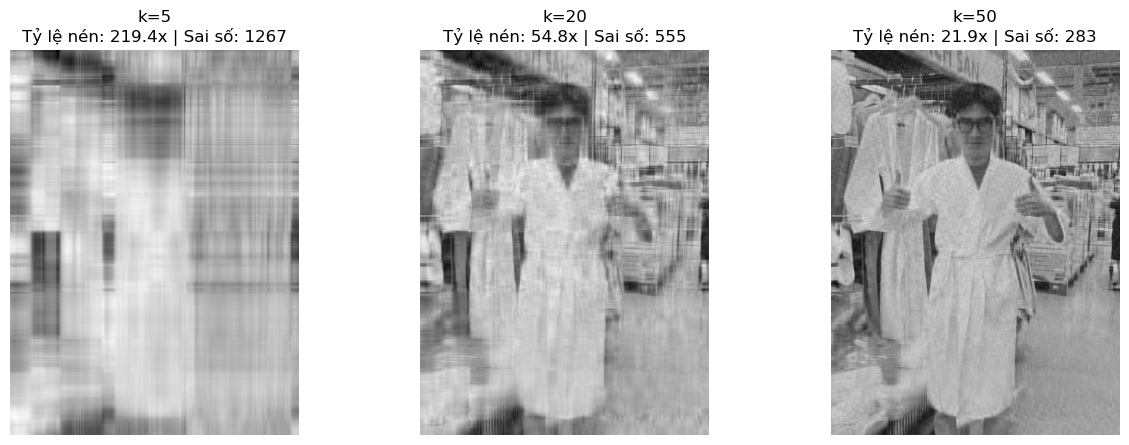

In [ ]:
# Lấy lại ảnh xám kích thước lớn ban đầu M_large
M = M_large.copy()
H, W = M.shape

# Phân rã SVD
U, S_diag, Vt = np.linalg.svd(M, full_matrices=False)

def reconstruct_and_evaluate(k):
    # Tái tạo ảnh với k
    M_k = U[:, :k] @ np.diag(S_diag[:k]) @ Vt[:k, :]
    
    # 1. Tỉ lệ nén = Kích thước lưu trữ nén / Kích thước ban đầu
    # Lưu U_k (H x k), S_k (k), Vt_k (k x W)
    compressed_size = (H * k) + k + (k * W)
    original_size = H * W
    compression_ratio = original_size / compressed_size 
    
    # 2. Sai số tái tạo (Dùng Mean Squared Error - MSE)
    reconstruction_error = np.mean((M - M_k) ** 2)
    
    return M_k, compression_ratio, reconstruction_error

     # 2.2 Hiển thị thử với k = 5, 20, 50 ---
k_values = [5, 20, 50]
plt.figure(figsize=(15, 5))
for i, k in enumerate(k_values):
    M_k, cr, err = reconstruct_and_evaluate(k)
    plt.subplot(1, 3, i+1)
    plt.imshow(M_k, cmap='gray')
    plt.title(f"k={k}\nTỷ lệ nén: {cr:.1f}x | Sai số: {err:.0f}")
    plt.axis('off')
plt.show()

       # 2.3: Vẽ đồ thị sai số theo k 
k_range = list(range(1, min(H, W), 10))
errors = []
for k in k_range:
    _, _, err = reconstruct_and_evaluate(k)
    errors.append(err)

plt.figure(figsize=(8, 4))
plt.plot(k_range, errors, marker='.')
plt.xlabel("Số lượng giá trị kỳ dị (k)")
plt.ylabel("Sai số tái tạo (MSE)")
plt.title("Đồ thị Sai số tái tạo theo k")
plt.grid(True)
plt.show()

# Tính Năng lượng tích lũy và tìm k giữ >= 90% thông tin 
energy = S_diag ** 2
cumulative_energy = np.cumsum(energy) / np.sum(energy)

# Tìm k nhỏ nhất sao cho năng lượng >= 0.90
k_90 = np.argmax(cumulative_energy >= 0.90) + 1

plt.figure(figsize=(8, 4))
plt.plot(cumulative_energy, label='Năng lượng tích lũy')
plt.axhline(y=0.90, color='r', linestyle='--', label='Ngưỡng 90%')
plt.axvline(x=k_90-1, color='g', linestyle='--', label=f'k = {k_90}')
plt.xlabel("Số lượng k")
plt.ylabel("Tỷ lệ thông tin (%)")
plt.title("Đồ thị Năng lượng tích lũy")
plt.legend()
plt.grid(True)
plt.show()

print(f"--> [BONUS] Để giữ lại >= 90% thông tin, cần chọn k = {k_90}")